<style>
.bpm-card {
  max-width: 920px;
  margin: 18px auto;
  background: linear-gradient(180deg, #3a0b1a 0%, #2b0610 100%);
  color: #efe9f1;
  border-radius: 16px;
  padding: 26px 34px;
  box-shadow: 0 8px 24px rgba(0,0,0,0.55), inset 0 1px 0 rgba(255,255,255,0.02);
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", Arial;
  line-height: 1.6;
  border: 1px solid rgba(255,255,255,0.03);
}
.bpm-card h2 {
  color: #ff4fb1; 
  font-size: 20px;
  margin: 0 0 12px 0;
  display: flex;
  align-items: center;
  gap: 10px;
  font-weight: 700;
}
.bpm-card .subtitle {
  color: rgba(255,255,255,0.85);
  margin-bottom: 12px;
  font-weight: 600;
}
.bpm-card ul {
  margin: 10px 0 0 0;
  padding: 0;
  list-style: none;
}
.bpm-card li {
  margin: 12px 0;
  padding-left: 8px;
  display: flex;
  gap: 10px;
  align-items: flex-start;
  font-size: 15px;
}
.bpm-card li .icon {
  font-size: 18px;
  line-height: 1.1;
  margin-top: 2px;
}
.bpm-card li strong {
  color: #ffffff;
}
.badge {
  display:inline-block;
  background: rgba(255,255,255,0.04);
  color: #d8b9d9;
  padding: 6px 10px;
  border-radius: 999px;
  font-size: 12px;
  margin-left: 8px;
  vertical-align: middle;
  border: 1px solid rgba(255,255,255,0.03);
}
</style>

<div class="bpm-card">
  <h2>🎵 Predicting the Beats-per-Minute of Songs — <span style="color:#ffd6f0;font-weight:700">Improved Notebook</span></h2>
  <div class="subtitle">Improved practical pitch prediction profile (BPM) using advanced methods and powerful feature analysis.</div>

  <ul>
    <li><span class="icon">🛠</span> <div><strong>Robust feature engineering</strong> — to capture musical patterns and meaningful audio signals.</div></li>
    <li><span class="icon">🔄</span> <div><strong>K-Fold cross-validation</strong> — for reliable performance evaluation and variance reduction.</div></li>
    <li><span class="icon">⚡</span> <div><strong>LightGBM with callbacks-based early stopping</strong> (compatible with older versions) to prevent overfitting.</div></li>
    <li><span class="icon">🌲</span> <div><strong>Optional XGBoost fallback</strong> — alternative gradient boosting implementation.</div></li>
    <li><span class="icon">🤝</span> <div><strong>Simple ensemble (LGBM + XGB)</strong> — small RMSE gain through model blending.</div></li>
    <li><span class="icon">📄</span> <div><strong>Clean submission generation</strong> — tidy pipeline to produce competition-ready CSV outputs.</div></li>
  </ul>

In [1]:

import os, sys, gc, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import lightgbm as lgb
from lightgbm import LGBMRegressor

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# LightGBM 
try:
    from lightgbm import LGBMRegressor, early_stopping
    LGBM_AVAILABLE = True
except Exception as e:
    print("LightGBM not available:", e)
    LGBM_AVAILABLE = False


In [2]:

# Paths
DATA_DIR = "/kaggle/input/playground-series-s5e9" if os.path.exists("/kaggle/input") else "."

train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

# If running locally, place train.csv and test.csv in working dir.
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(train.shape, test.shape)
display(train.head())


(524164, 11) (174722, 10)


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


## Basic EDA

## Data Visualization

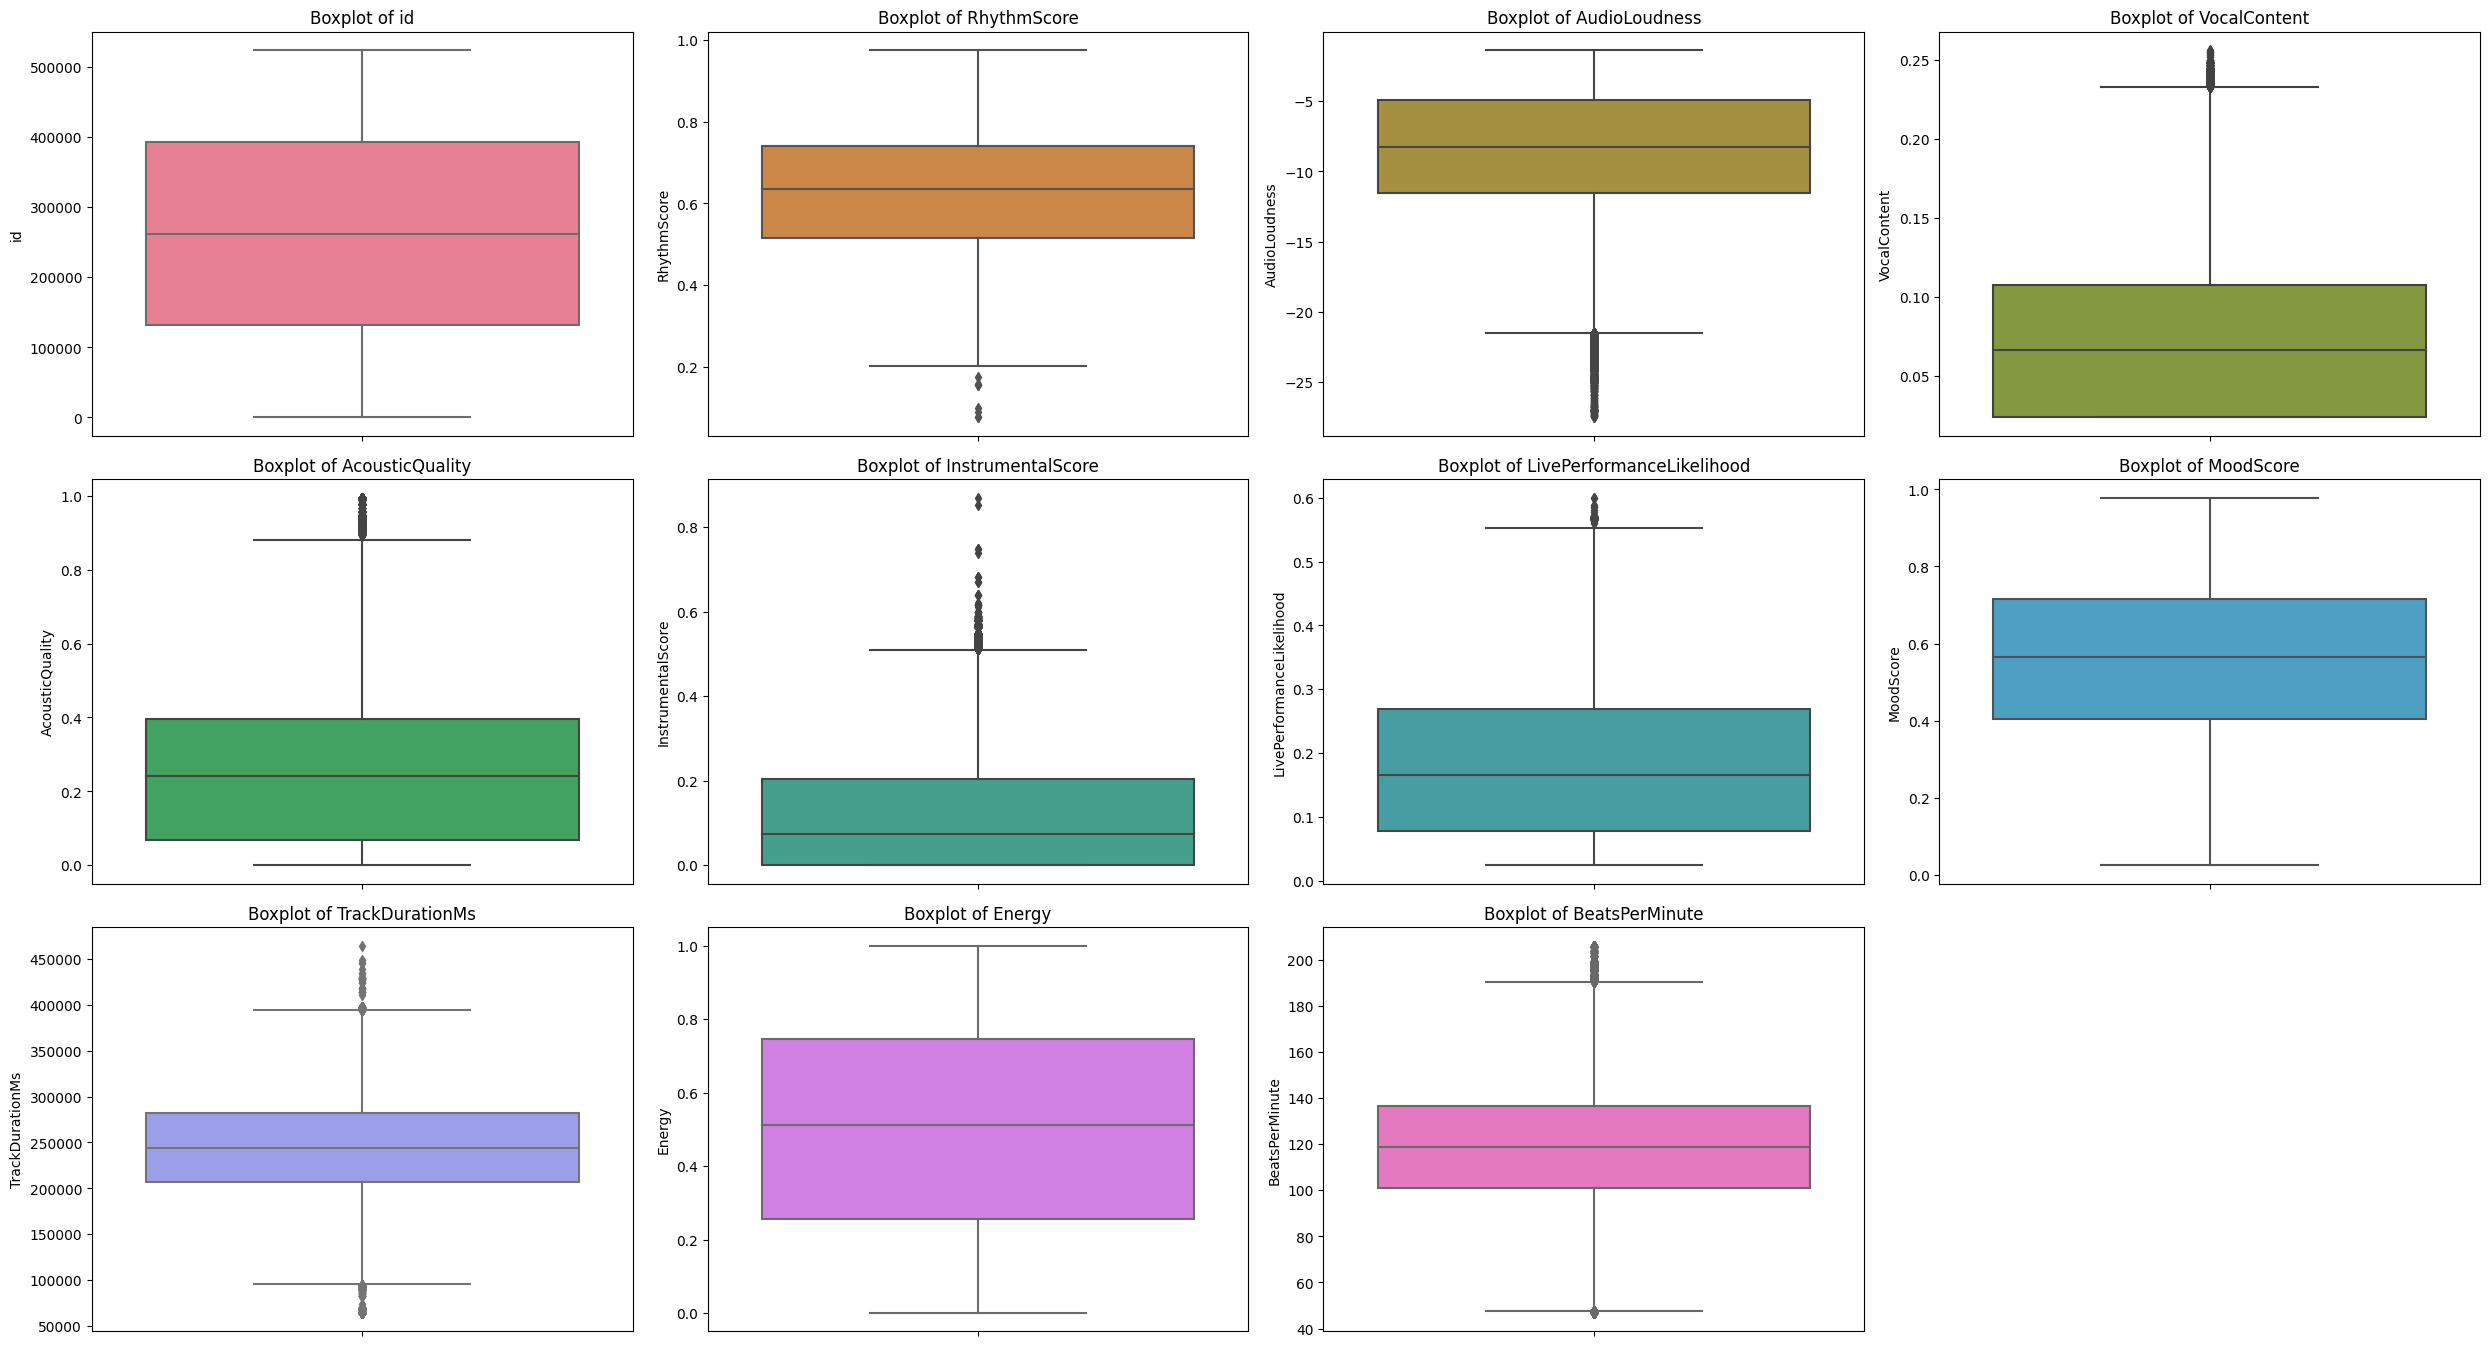

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns

# Define color palette
palette = sns.color_palette("husl", len(numerical_cols))

#to show Outliers in data 
plt.figure(figsize=(25, 18))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=train[col], color=palette[i-1])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [4]:
# Define color palette
#palette = sns.color_palette("husl", len(numerical_cols))

#to show Distribution
#plt.figure(figsize=(25, 15))
#for i, col in enumerate(numerical_cols, 1):
#    plt.subplot(4, 4, i)
#    sns.histplot(train[col], kde=True, color=palette[i-1], bins=30)
#    plt.title(f'Distribution of {col}')
#plt.tight_layout()
#plt.show()

## Feature Engineering

In [5]:

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Duration features
    df["TrackDurationMin"] = df["TrackDurationMs"] / 60000.0
    df["TrackDurationSec"] = df["TrackDurationMs"] / 1000.0
    df["LogDuration"] = np.log1p(df["TrackDurationMs"])

    # Interaction features
    df["Rhythm_Energy"] = df["RhythmScore"] * df["Energy"]
    df["Acoustic_Vocal"] = df["AcousticQuality"] * df["VocalContent"]
    df["Mood_Live"] = df["MoodScore"] * df["LivePerformanceLikelihood"]

    # Pairwise ratios (safe division)
    eps = 1e-6
    df["Energy_over_Rhythm"] = df["Energy"] / (df["RhythmScore"] + eps)
    df["Vocal_over_Acoustic"] = df["VocalContent"] / (df["AcousticQuality"] + eps)

    # Polynomial terms
    for col in ["RhythmScore","Energy","MoodScore","AudioLoudness","AcousticQuality","VocalContent"]:
        df[f"{col}_sq"] = df[col] ** 2

    # Binning duration
    df["DurationBin"] = pd.qcut(df["TrackDurationMin"], q=10, duplicates='drop').cat.codes

    return df

train_fe = add_features(train)
test_fe = add_features(test)

print("Train columns:", len(train_fe.columns))
display(train_fe.head())


Train columns: 26


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,...,Mood_Live,Energy_over_Rhythm,Vocal_over_Acoustic,RhythmScore_sq,Energy_sq,MoodScore_sq,AudioLoudness_sq,AcousticQuality_sq,VocalContent_sq,DurationBin
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,...,0.021061,1.368873,3694.968553,0.364345,0.682717,0.167990,58.322884,2.872960e-11,0.000552,7
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,...,0.111012,0.227382,0.160743,0.408898,0.021141,0.423814,264.634753,1.979619e-01,0.005115,1
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,...,0.012536,1.214032,0.637391,0.264749,0.390208,0.179662,254.516559,3.017122e-02,0.012258,1
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,...,0.024074,0.663704,32.064077,0.539435,0.237624,0.077699,1.841449,2.725263e-06,0.002805,3
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,...,0.158307,1.777463,0.342127,0.284055,0.897440,0.228263,170.470560,4.717899e-03,0.000552,2


## Prepare Features & Target

In [6]:

TARGET = "BeatsPerMinute"
ID = "id"

features = [c for c in train_fe.columns if c not in [TARGET, ID]]
X = train_fe[features]
y = train_fe[TARGET]
X_test = test_fe[features]

X.shape, X_test.shape


((524164, 24), (174722, 24))

## Simple Ensemble

## 💡 Idea:

- The code tries different weights (0.5, 0.6, 0.7, 0.8).

- It prints you the RMSE for each weight.

- It selects the best weight automatically.

## Version 12 with Score: 26.38583


In [7]:
# different model from LGBM

#models = [
#    LGBMRegressor(                         # Model 1
#        num_leaves=25, learning_rate=0.005, n_estimators=550,
#        max_depth=30, min_child_samples=15,
#        subsample=1.0, colsample_bytree=1.0,
#        reg_alpha=1.0, reg_lambda=0.5,
#        random_state=42, n_jobs=-1
#    ),
#    LGBMRegressor(                         # Model 2
#        num_leaves=38, learning_rate=0.009, n_estimators=800,
#        max_depth=35, min_child_samples=20,
#        subsample=0.8, colsample_bytree=0.8,
#        reg_alpha=0.5, reg_lambda=0.5,
#        random_state=52, n_jobs=-1
#    ),
#    LGBMRegressor(                         # Model 3
#        num_leaves=30, learning_rate=0.004, n_estimators=650,
#        max_depth=25, min_child_samples=10,
#        subsample=0.9, colsample_bytree=0.9,
#        reg_alpha=1.0, reg_lambda=1.0,
#        random_state=99, n_jobs=-1
#    )
#]
#
# trainig & evalute
#oof_preds = []
#test_preds = []

#for i, model in enumerate(models, 1):
#    model.fit(X, y)
#    pred_train = model.predict(X)
#    pred_test = model.predict(X_test)
#
#    rmse = mean_squared_error(y, pred_train, squared=False)
#    print(f"Model {i} RMSE: {rmse:.6f}")

#    oof_preds.append(pred_train)
#    test_preds.append(pred_test)

 #average ensemble
#oof_blend = np.mean(oof_preds, axis=0)
#test_blend = np.mean(test_preds, axis=0)

#rmse_blend = mean_squared_error(y, oof_blend, squared=False)
#print(f"Ensemble Blend RMSE: {rmse_blend:.6f}")

# final result
#final_preds = test_blend


<style>
.results-card {
  max-width: 920px;
  margin: 18px auto;
  background: linear-gradient(180deg, #063a22 0%, #052a19 100%);
  color: #e6ffee;
  border-radius: 16px;
  padding: 26px 34px;
  box-shadow: 0 8px 24px rgba(0,0,0,0.55), inset 0 1px 0 rgba(255,255,255,0.02);
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", Arial;
  line-height: 1.6;
  border: 1px solid rgba(255,255,255,0.05);
}
.results-card h2 {
  color: #5fffb2; /* أخضر فاتح */
  font-size: 20px;
  margin: 0 0 12px 0;
  display: flex;
  align-items: center;
  gap: 10px;
  font-weight: 700;
}
.results-card ul {
  margin: 10px 0 0 0;
  padding: 0;
  list-style: none;
}
.results-card li {
  margin: 12px 0;
  padding-left: 8px;
  display: flex;
  gap: 10px;
  align-items: flex-start;
  font-size: 15px;
}
.results-card li .icon {
  font-size: 18px;
  line-height: 1.1;
  margin-top: 2px;
}
.results-card li strong {
  color: #ffffff;
}
</style>

<div class="results-card">
  <h2>📊 Model Performance (RMSE Results)</h2>
  <ul>
    <li><span class="icon">🔀</span> <div><strong>Ensemble Blend RMSE</strong>: 26.405313</div></li>
    <li><span class="icon">🎯</span> <div><strong>Model 1</strong> ⇒ RMSE: 26.432003</div></li>
    <li><span class="icon">🎯</span> <div><strong>Model 2</strong> ⇒ RMSE: 26.357965</div></li>
    <li><span class="icon">🎯</span> <div><strong>Model 3</strong> ⇒ RMSE: 26.428147</div></li>
  </ul>
</div>


<!-- الصندوق الملون لعرض CV Scores و Training RMSE -->
<style>
.cv-card {
  max-width: 920px;
  margin: 18px auto;
  background: linear-gradient(180deg, #4a1f00 0%, #2d1300 100%);
  color: #fff2e6;
  border-radius: 16px;
  padding: 26px 34px;
  box-shadow: 0 8px 24px rgba(0,0,0,0.55), inset 0 1px 0 rgba(255,255,255,0.02);
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", Arial;
  line-height: 1.6;
  border: 1px solid rgba(255,255,255,0.05);
}
.cv-card h2 {
  color: #ffb366; /* برتقالي فاتح */
  font-size: 20px;
  margin: 0 0 12px 0;
  display: flex;
  align-items: center;
  gap: 10px;
  font-weight: 700;
}
.cv-card ul {
  margin: 10px 0 0 0;
  padding: 0;
  list-style: none;
}
.cv-card li {
  margin: 12px 0;
  padding-left: 8px;
  display: flex;
  gap: 10px;
  align-items: flex-start;
  font-size: 15px;
}
.cv-card li .icon {
  font-size: 18px;
  line-height: 1.1;
  margin-top: 2px;
}
.cv-card li strong {
  color: #ffffff;
}
</style>

<div class="cv-card">
  <h2>📈 Cross-Validation & Training Metrics V 17</h2>
  <ul>
    <li><span class="icon">📊</span> <div><strong>Mean CV RMSE</strong>: 26.460701 (±0.022078)</div></li>
    <li><span class="icon">🏋️</span> <div><strong>Training RMSE</strong>: 26.408334</div></li>
    <li><span class="icon">📑</span> <div><strong>CV RMSE Scores</strong>: ['26.473184', '26.479243', '26.429675']</div></li>
    <li><span class="icon">🔥</span> <div><strong>Model Of V 12 </strong> ⇒ score: 26.38705</div></li>
    <li><span class="icon">✨</span> <div><strong>The Version 12</strong> 🚀</div></li>
  </ul>
</div>


<style>
.config-card {
  max-width: 920px;
  margin: 18px auto;
  background: linear-gradient(180deg, #0a223a 0%, #071727 100%);
  color: #e8f1ff;
  border-radius: 16px;
  padding: 26px 34px;
  box-shadow: 0 8px 24px rgba(0,0,0,0.55), inset 0 1px 0 rgba(255,255,255,0.02);
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", Arial;
  line-height: 1.6;
  border: 1px solid rgba(255,255,255,0.05);
}
.config-card h2 {
  color: #6fc3ff; 
  font-size: 20px;
  margin: 0 0 12px 0;
  display: flex;
  align-items: center;
  gap: 10px;
  font-weight: 700;
}
.config-card ul {
  margin: 10px 0 0 0;
  padding: 0;
  list-style: none;
}
.config-card li {
  margin: 12px 0;
  padding-left: 8px;
  display: flex;
  gap: 10px;
  align-items: flex-start;
  font-size: 15px;
}
.config-card li .icon {
  font-size: 18px;
  line-height: 1.1;
  margin-top: 2px;
}
.config-card li strong {
  color: #ffffff;
}
</style>

<div class="config-card">
  <h2>⚙️ Structured Model Configuration & Improvements</h2>
  <ul>
    <li><span class="icon">📋</span> <div><strong>Structured Model Configuration</strong>: Each model has a name and configuration for better tracking.</div></li>
    <li><span class="icon">🔄</span> <div><strong>Cross-Validation</strong>: Added proper CV evaluation to prevent overfitting assessment.</div></li>
    <li><span class="icon">📊</span> <div><strong>Enhanced Hyperparameters</strong>: Added more LightGBM parameters for better control.</div></li>
    <li><span class="icon">⚠️</span> <div><strong>Error Handling</strong>: Added warnings filter and verbose control.</div></li>
    <li><span class="icon">🤝</span> <div><strong>Weighted Ensemble</strong>: Option to weight models based on their CV performance.</div></li>
    <li><span class="icon">🖨</span> <div><strong>Better Output</strong>: More informative printing with scores and statistics.</div></li>
    <li><span class="icon">💾</span> <div><strong>Model Persistence</strong>: Function to save trained models for future use.</div></li>
    <li><span class="icon">🧠</span> <div><strong>Memory Efficiency</strong>: Optimized prediction storage.</div></li>
    <li><span class="icon">🔧</span> <div><strong>Flexibility</strong>: Easy to add more models or modify configurations.</div></li>
  </ul>
</div>


In [8]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Define Models (only 2)
models = [
    {
        'name': 'LGBM_Fast1',
        'model': LGBMRegressor(
            num_leaves=33, learning_rate=0.03, n_estimators=300,
            max_depth=10, min_child_samples=20, subsample=0.8,
            colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
            random_state=42, n_jobs=-1, verbose=-1, boosting_type='gbdt'
        )
    },
    {
        'name': 'LGBM_Fast2',
        'model': LGBMRegressor(
            num_leaves=28, learning_rate=0.02, n_estimators=250,
            max_depth=12, min_child_samples=15, subsample=0.7,
            colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=0.5,
            random_state=52, n_jobs=-1, verbose=-1, boosting_type='gbdt'
        )
    }
]


# Training Function
def train_and_evaluate_models_fast(X, y, X_test, n_splits=3):
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros((len(X_test), len(models)))
    cv_scores = []
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for model_idx, model_config in enumerate(models):
        model = model_config['model']
        model_name = model_config['name']
        
        print(f"\nTraining {model_name}...")
        print("=" * 30)
        
        # Cross-validation
        cv_rmse = np.sqrt(-cross_val_score(
            model, X, y, scoring='neg_mean_squared_error',
            cv=kf, n_jobs=1
        ))
        
        print(f"CV RMSE Scores: {[f'{x:.6f}' for x in cv_rmse]}")
        print(f"Mean CV RMSE: {cv_rmse.mean():.6f} (±{cv_rmse.std():.6f})")
        cv_scores.append(cv_rmse.mean())
        
        # Train full model
        model.fit(X, y)
        
        # Predictions
        pred_train = model.predict(X)
        pred_test = model.predict(X_test)
        
        oof_preds += pred_train / len(models)
        test_preds[:, model_idx] = pred_test
        
        # Training RMSE
        train_rmse = mean_squared_error(y, pred_train, squared=False)
        print(f"Training RMSE: {train_rmse:.6f}")
    
    return oof_preds, test_preds, cv_scores


# Run Training
oof_blend, test_preds_matrix, cv_scores = train_and_evaluate_models_fast(X, y, X_test)

# Simple Ensemble (average)
test_blend = np.mean(test_preds_matrix, axis=1)

# Weighted Ensemble (better)
weights = 1 / np.array(cv_scores)
weights = weights / weights.sum()
test_weighted_blend = np.average(test_preds_matrix, axis=1, weights=weights)

# Final predictions
final_preds = test_weighted_blend  # or test_blend


# Save Submission
ID = "id"  
TARGET = "BeatsPerMinute"  

sub = pd.DataFrame({
    ID: test[ID],
    TARGET: final_preds
})

sub_path = "submission.csv"
sub.to_csv(sub_path, index=False)
print(f"\n✅ Saved submission file to: {sub_path}")
print(sub.head())



Training LGBM_Fast1...
CV RMSE Scores: ['26.477838', '26.484505', '26.432256']
Mean CV RMSE: 26.464867 (±0.023219)
Training RMSE: 26.351571

Training LGBM_Fast2...
CV RMSE Scores: ['26.472297', '26.480011', '26.430329']
Mean CV RMSE: 26.460879 (±0.021830)
Training RMSE: 26.406242

✅ Saved submission file to: submission.csv
       id  BeatsPerMinute
0  524164      119.589265
1  524165      118.541774
2  524166      119.454838
3  524167      119.238178
4  524168      119.505353
